In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [36]:
import numpy as np
import cv2
from PIL import Image, ImageOps
import torchvision.transforms as transforms

class PreprocessingTransform:
    def __call__(self, img):
        # Invertuj sliku
        img = img.convert("RGB")
        img_inv = ImageOps.invert(img)

        # Dilacija
        img_np = np.array(img_inv)
        kernel = np.ones((2, 2), np.uint8)
        dilated = cv2.dilate(img_np, kernel, iterations=1)

        # Nazad u PIL format kao RGB
        img_pil = Image.fromarray(dilated).convert("RGB")
        return img_pil

In [37]:
# PREPROCESIRANJE KOJE TREBA DA BUDE UNUTAR DATASETA

preprocess = transforms.Compose([
    PreprocessingTransform(),                    # tvoj deo
    transforms.Resize((227, 227)),               # resize za VGG
    transforms.ToTensor(),                       # u tensor
    transforms.Normalize(                        # normalizacija za VGG
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [38]:
import os
from PIL import Image
from torch.utils.data import Dataset

class QuickDraw0Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}  # novo: mapiranje indeks → naziv
        self.classes = []       # novo: lista imena klasa

        # Pronađi sve klase (nazive foldera)
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                self.classes.append(class_name)
                for fname in os.listdir(class_path):
                    if fname.endswith(('.png', '.jpg', '.jpeg')):
                        self.samples.append((os.path.join(class_path, fname), class_name))  # ovde dodaješ naziv klase

    def __len__(self):
        return len(self.samples)

    '''
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('L')
        if self.transform:
            image = self.transform(image)
        return image, class_name  # vraćamo naziv klase kao label
    '''
    
    def __getitem__(self, idx):
        image_path, class_name = self.samples[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[class_name]  # vrati int umesto string
        return image, label

In [39]:
import torchvision.transforms as transforms
direc = "balanced_chosen_3_images"
'''
transform = transforms.Compose([
    transforms.Resize((227, 227)),  # ekvivalent cv2.resize
    transforms.ToTensor(),          # automatski skalira u [0, 1]
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],       # opcionalna normalizacija (centar na 0)
        std=[0.5, 0.5, 0.5]
    )
])'''

dataset = QuickDraw0Dataset(direc, transform=preprocess)

In [24]:
# MOZDA BUDE POTREBNO, TRENUTNO NE SLUZI NICEMU
from torch.utils.data import Subset


def create_subset(dataset, fraction=0.25):
    total_size = len(dataset)
    subset_size = int(total_size * fraction)
    
    indices = list(range(total_size))
    subset_indices = indices[:subset_size]
    
    return Subset(dataset, subset_indices)


subset_dataset = create_subset(dataset, fraction=0.25)

In [40]:
from torch.utils.data import Dataset, DataLoader, random_split

# Podeli dataset na trening (70%), validacioni (15%) i test set (15%)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [41]:
# Kreiraj DataLoader-e
batchsize = 64
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batchsize, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batchsize, shuffle=False)

In [42]:
class AlexNet(nn.Module):
        def __init__(self, num_classes):
            super(AlexNet, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
                nn.BatchNorm2d(96),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer3 = nn.Sequential(
                nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer4 = nn.Sequential(
                nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer5 = nn.Sequential(
                nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(9216, 4096),
                nn.ReLU())
            self.fc1 = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(4096, 4096),
                nn.ReLU())
            self.fc2= nn.Sequential(
                nn.Linear(4096, num_classes))

        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.layer4(out)
            out = self.layer5(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.fc1(out)
            out = self.fc2(out)
            return out

In [13]:
pip install torchsummary

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [10]:

from torchsummary import summary
# Instantiate model
alexnet = AlexNet(3)
# Get complete summary of AlexNet
summary(alexnet, (3, 227, 227), batch_size=128)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [128, 96, 55, 55]          34,944
       BatchNorm2d-2          [128, 96, 55, 55]             192
              ReLU-3          [128, 96, 55, 55]               0
         MaxPool2d-4          [128, 96, 27, 27]               0
            Conv2d-5         [128, 256, 27, 27]         614,656
       BatchNorm2d-6         [128, 256, 27, 27]             512
              ReLU-7         [128, 256, 27, 27]               0
         MaxPool2d-8         [128, 256, 13, 13]               0
            Conv2d-9         [128, 384, 13, 13]         885,120
      BatchNorm2d-10         [128, 384, 13, 13]             768
             ReLU-11         [128, 384, 13, 13]               0
           Conv2d-12         [128, 384, 13, 13]       1,327,488
      BatchNorm2d-13         [128, 384, 13, 13]             768
             ReLU-14         [128, 384,

In [11]:
print(device)

cpu


In [43]:
import torch.optim as optim

#os.makedirs("saved_models_top3_vgg_0", exist_ok=True)
#alexnet.load_state_dict(torch.load("saved_models/alexnet/model_epoch_9.pth"))
#alexnet.to(device)
start = 0
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(alexnet.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(start, 10):  # Run for 10 epochs
    alexnet.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%')
    model_path = f"saved_models/alexnet0/model_epoch_{epoch+1}.pth"
    torch.save(alexnet.state_dict(), model_path)

    alexnet.eval()
    val_loss = 0.0
    with torch.no_grad():
        for input_image, target_image in val_loader:
            input_image = input_image.to(device)
            target_image = target_image.to(device)
            outputs = alexnet(input_image)
            loss = criterion(outputs, target_image)
            val_loss += loss.item()
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Validation Loss: {val_loss/len(val_loader)}, Accuracy: {100 * correct / total:.2f}%")

Epoch [1/10], Loss: 0.7745, Accuracy: 69.52%
Validation Loss: 0.4530666694045067, Accuracy: 72.66%
Epoch [2/10], Loss: 0.2972, Accuracy: 90.62%
Validation Loss: 0.3336193785071373, Accuracy: 91.22%
Epoch [3/10], Loss: 0.1950, Accuracy: 94.00%
Validation Loss: 0.22504443558864295, Accuracy: 94.67%
Epoch [4/10], Loss: 0.1284, Accuracy: 95.90%
Validation Loss: 0.13512697542319074, Accuracy: 96.26%
Epoch [5/10], Loss: 0.1078, Accuracy: 96.71%
Validation Loss: 0.1498865693283733, Accuracy: 96.94%
Epoch [6/10], Loss: 0.0918, Accuracy: 96.86%
Validation Loss: 0.20046964287757874, Accuracy: 96.42%
Epoch [7/10], Loss: 0.0657, Accuracy: 97.76%
Validation Loss: 0.13679126618080772, Accuracy: 97.18%
Epoch [8/10], Loss: 0.0534, Accuracy: 98.33%
Validation Loss: 0.13595997703669127, Accuracy: 97.97%
Epoch [9/10], Loss: 0.0475, Accuracy: 98.57%
Validation Loss: 0.1444633763458114, Accuracy: 98.81%
Epoch [10/10], Loss: 0.0365, Accuracy: 98.76%
Validation Loss: 0.1492726067408512, Accuracy: 98.65%


In [45]:
import torch
from torchvision import models
from sklearn.metrics import classification_report
from tqdm import tqdm  # za lepši prikaz progres bara (opciono)
'''
# 1. Učitaj model i prebaci na eval mod
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pretpostavka: imaš 10 klasa (prilagodi ako je drugačije)
num_classes = 10

# Inicijalizuj model i zameni poslednji sloj
model = models.vgg16(pretrained=False)
model.classifier[6] = torch.nn.Linear(4096, num_classes)
'''

# Učitaj težine
alexnet.load_state_dict(torch.load('saved_models/alexnet0/model_epoch_10.pth', map_location=device))
alexnet = alexnet.to(device)
alexnet.eval()

# 2. Evaluacija
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 3. Izračunaj metrike
print("=== Izveštaj klasifikacije ===")
print(classification_report(y_true, y_pred, digits=4))

100%|██████████| 8/8 [00:05<00:00,  1.44it/s]

=== Izveštaj klasifikacije ===
              precision    recall  f1-score   support

           0     0.9504    0.9781    0.9640       137
           1     0.9747    0.9222    0.9477       167
           2     0.9404    0.9726    0.9562       146

    accuracy                         0.9556       450
   macro avg     0.9551    0.9576    0.9560       450
weighted avg     0.9562    0.9556    0.9554       450



In [46]:
train_loss = [0.7745, 0.2972, 0.1950, 0.1284, 0.1078, 0.0918, 0.0657, 0.0534, 0.0475, 0.0365]
train_accuracy = [69.52, 90.62, 94.00, 95.90, 96.71, 96.86, 97.76, 98.33, 98.57, 98.76]
val_loss = [0.4531, 0.3336, 0.2250, 0.1351, 0.1499, 0.2005, 0.1368, 0.1360, 0.1445, 0.1493]
val_accuracy = [72.66, 91.22, 94.67, 96.26, 96.94, 96.42, 97.18, 97.97, 98.81, 98.65]

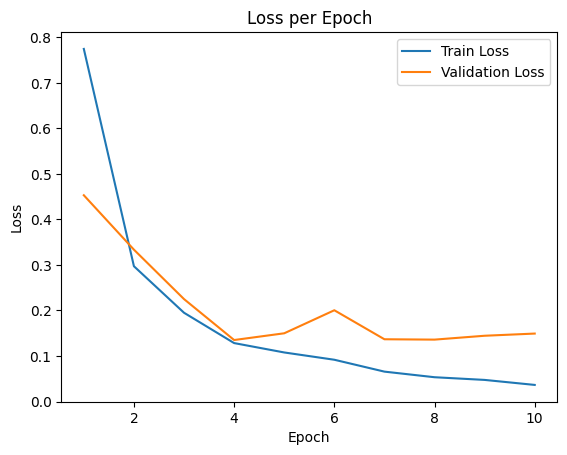

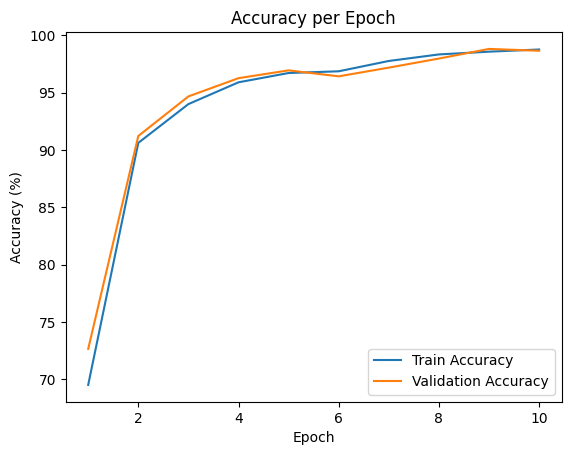

: 

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.show()

plt.plot(epochs, train_accuracy, label="Train Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy per Epoch")
plt.show()